# Cloud nowcasting over Ireland

**Goal:** look at the last 30 minutes of satellite images and predict **where the (cold-topped) clouds will be** 15, 30 and 60 minutes from now.

We'll go through the whole pipeline, one step at a time:

1. **Collect data:** download satellite images (free, no login needed)
2. **Look at the data:** plot a satellite image and check it's really Ireland
3. **Make labels:** turn temperatures into a "cloud / no cloud" map
4. **Build training examples:** pair *past images* with *future cloud maps*
5. **Build a neural network:** a small U-Net
6. **Train it**, watching a separate validation set
7. **Evaluate it:** is it better than "nothing changes" and "clouds keep moving the same way"?

**The data:** the European weather satellite **Meteosat (SEVIRI instrument)** takes a picture of Europe every 5 minutes.
It measures infrared "brightness temperature" in several channels. Cold = high cloud tops, warm = ground, sea or low cloud.
We fetch our data from Eumestat public dataset, so we'll use that.

**Packages you need:**
`pip install numpy pandas xarray "zarr<3" gcsfs ocf_blosc2 pyresample pyproj matplotlib torch`


## 0. Imports and settings

In [40]:
import hashlib
import json
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import ocf_blosc2  # not used directly: importing it registers the archive's compression codec with zarr
from pyproj import Transformer
from pyresample.area_config import load_area_from_string

# Reproducibility: seed every random number generator we use, and ask the GPU for deterministic algorithms
SEED = 101
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [41]:
# Settings you can play with

# Which days to download (one archive file per year, 2008-2022). Spreading days over the whole
# year gives the model summer AND winter weather. Each day takes ~20 s to download.
DAYS = pd.date_range("2021-01-05", "2021-12-31", freq="15D")   # 25 days, one every ~2 weeks

# Train / validation / test split, by whole days, spread across the year so every set sees every season.
# Days that actually have data are numbered 0, 1, 2, ... (the archive has gaps, so some days are skipped):
# day 0,1,3,5,6,8,... -> train;  every 5th day starting at day 2 -> validation;  starting at day 4 -> test
def split_of_day(n):
    return {2: "val", 4: "test"}.get(n % 5, "train")

# Satellite channels to use (infrared / water vapour only).
# IR_039 is left out on purpose: in daytime it also measures reflected sunlight, so its values
# jump at sunrise and sunset, which would confuse the model.
CHANNELS = ["WV_062", "WV_073", "IR_087", "IR_108", "IR_120", "IR_134"]

LON_MIN, LON_MAX, LAT_MIN, LAT_MAX = -18, -2, 48, 58   # area to download (extra space west for incoming Atlantic weather)
IRELAND = dict(lon=(-10.7, -5.3), lat=(51.3, 55.5))    # area we score the forecasts on

HISTORY = 6              # model sees 6 frames = the last 30 minutes (one frame every 5 min)
LEADS = [3, 6, 12]       # predict 3, 6 and 12 frames ahead = +15, +30, +60 minutes
CLOUD_THRESHOLD_K = 270  # a pixel colder than 270 K (-3 °C) in channel IR_108 counts as "cold cloud"

# The saved-data file name contains a fingerprint of the settings above, so changing
# DAYS, CHANNELS or the area makes the notebook download fresh data instead of reusing old data.
config = dict(days=[str(d.date()) for d in DAYS], channels=CHANNELS, box=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])
fingerprint = hashlib.md5(json.dumps(config).encode()).hexdigest()[:8]
DATA_FILE = Path(f"data/notebook_data_{fingerprint}.npz")
print("Data file:", DATA_FILE)

Data file: data/notebook_data_b35fdd3e.npz


## 1. Collect data

The archive is one huge [zarr](https://zarr.dev) dataset per year covering all of Europe.
`xarray` opens it *lazily*: nothing is downloaded until we ask for actual numbers.
So we first cut out a box around Ireland, then download only that part.

In [42]:
ARCHIVE_URL = "gs://public-datasets-eumetsat-solar-forecasting/satellite/EUMETSAT/SEVIRI_RSS/v4/{year}_nonhrv.zarr"

archive = xr.open_zarr(ARCHIVE_URL.format(year=2021), storage_options={"token": "anon"})
print(archive.data.dims, archive.data.shape)
print("channels:", list(archive.variable.values))

('time', 'y_geostationary', 'x_geostationary', 'variable') (88225, 1392, 3712, 11)
channels: [np.str_('IR_016'), np.str_('IR_039'), np.str_('IR_087'), np.str_('IR_097'), np.str_('IR_108'), np.str_('IR_120'), np.str_('IR_134'), np.str_('VIS006'), np.str_('VIS008'), np.str_('WV_062'), np.str_('WV_073')]


The satellite grid isn't in latitude/longitude: it's in "geostationary" coordinates (metres, as seen from the
satellite). We convert the edges of our lat/lon box into those coordinates and then pick the grid rows and
columns whose **coordinate values** fall inside, so there's no guessing about which way the array is stored.

In [43]:
satellite_grid = load_area_from_string(archive.data.attrs["area"])
to_geos = Transformer.from_crs("EPSG:4326", satellite_grid.crs, always_xy=True)
to_latlon = Transformer.from_crs(satellite_grid.crs, "EPSG:4326", always_xy=True)

# Walk around the edge of the lat/lon box (edges become curves in satellite coordinates)
t = np.linspace(0, 1, 50)
edge_lon = np.concatenate([LON_MIN + t * (LON_MAX - LON_MIN), np.full(50, LON_MAX),
                           LON_MIN + t * (LON_MAX - LON_MIN), np.full(50, LON_MIN)])
edge_lat = np.concatenate([np.full(50, LAT_MIN), LAT_MIN + t * (LAT_MAX - LAT_MIN),
                           np.full(50, LAT_MAX), LAT_MIN + t * (LAT_MAX - LAT_MIN)])
edge_x, edge_y = to_geos.transform(edge_lon, edge_lat)

x_all, y_all = archive.x_geostationary.values, archive.y_geostationary.values
col_idx = np.where((x_all >= edge_x.min()) & (x_all <= edge_x.max()))[0]
row_idx = np.where((y_all >= edge_y.min()) & (y_all <= edge_y.max()))[0]
cols, rows = slice(col_idx.min(), col_idx.max() + 1), slice(row_idx.min(), row_idx.max() + 1)
print("rows:", rows, " columns:", cols)

rows: slice(np.int64(992), np.int64(1178), None)  columns: slice(np.int64(2063), np.int64(2469), None)


In [44]:
def shrink(x):
    # Average 2x2 blocks to halve the resolution (so training is fast, even on a CPU).
    # Also trims the size to a multiple of 4, which the U-Net needs later.
    h, w = x.shape[-2] // 8 * 4, x.shape[-1] // 8 * 4
    x = x[..., : h * 2, : w * 2].astype(np.float32)
    return x.reshape(*x.shape[:-2], h, 2, w, 2).mean(axis=(-3, -1))


def shrink_coords(v, n):
    # Same 2x averaging for a 1-D coordinate array, keeping the first n output values
    return v[: n * 2].reshape(n, 2).mean(axis=1)


def download_day(day):
    # Download one day (up to 288 images) of our channels over the box, and shrink it straight away
    ds = xr.open_zarr(ARCHIVE_URL.format(year=day.year), storage_options={"token": "anon"})
    part = ds.data.isel(y_geostationary=rows, x_geostationary=cols).sel(variable=CHANNELS)
    part = part.sel(time=slice(day, day + pd.Timedelta(hours=23, minutes=59)))
    # Sort by coordinate value so north is up (y decreasing) and west is left (x increasing)
    part = part.sortby("y_geostationary", ascending=False).sortby("x_geostationary")
    part = part.transpose("time", "variable", "y_geostationary", "x_geostationary")
    if part.sizes["time"] == 0:                            # the archive has gaps: some days have no images
        return None
    images = part.values                                   # (time, channel, y, x), values scaled to 0..1
    small = np.concatenate([shrink(images[k : k + 48]) for k in range(0, len(images), 48)])
    return (pd.DatetimeIndex(part.time.values), small.astype(np.float16),
            part.x_geostationary.values, part.y_geostationary.values)


if DATA_FILE.exists():
    saved = np.load(DATA_FILE)
    times, X, lat, lon = pd.DatetimeIndex(saved["times"]), saved["images"], saved["lat"], saved["lon"]
    print("Loaded saved data from", DATA_FILE)
else:
    all_times, all_images = [], []
    for day in DAYS:
        result = download_day(day)
        if result is None:
            print(f"{day:%Y-%m-%d}: no images in the archive, skipping this day")
            continue
        t, img, x_crop, y_crop = result
        print(f"{day:%Y-%m-%d}: {len(t)} images")
        all_times.append(t)
        all_images.append(img)
    times, X = all_times[0].append(all_times[1:]), np.concatenate(all_images)
    # latitude / longitude of the centre of every (shrunk) pixel
    xs, ys = shrink_coords(x_crop, X.shape[-1]), shrink_coords(y_crop, X.shape[-2])
    lon, lat = to_latlon.transform(*np.meshgrid(xs, ys))
    DATA_FILE.parent.mkdir(exist_ok=True)
    np.savez(DATA_FILE, times=times.values, images=X, lat=lat, lon=lon, config=json.dumps(config))

print("images shape (time, channel, y, x):", X.shape, f"= {X.nbytes / 1e9:.1f} GB in memory")

Loaded saved data from data/notebook_data_b35fdd3e.npz
images shape (time, channel, y, x): (6048, 6, 92, 200) = 1.3 GB in memory


## 2. Look at the data

The archive stores every channel squeezed into the range 0..1. For `IR_108` we can convert back to
temperature in kelvin with a simple formula (the numbers come from the archive's documentation).

The red dots are four cities placed using their latitude/longitude. If they land on the Irish coastline
shapes, our cut-out is in the right place and the right way round. The dashed line is the area we'll
score forecasts on.

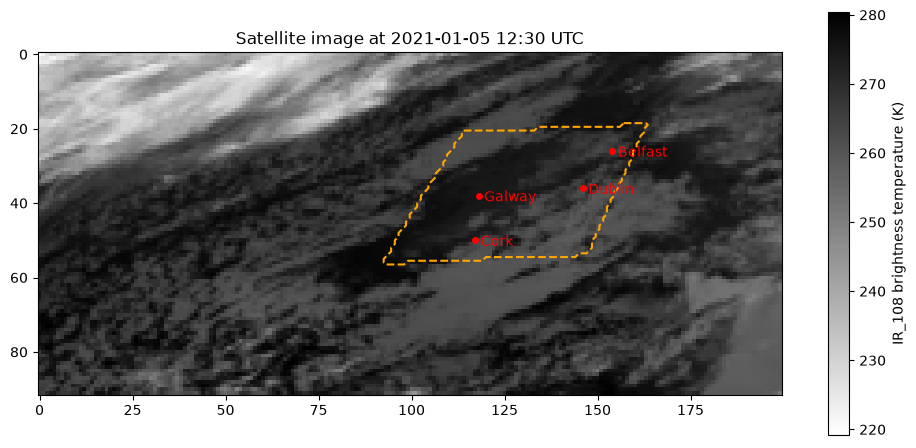

In [45]:
IR108_MIN, IR108_MAX = 199.10002, 313.2767   # kelvin that 0 and 1 correspond to
ir108 = CHANNELS.index("IR_108")


def to_kelvin(scaled):
    return IR108_MIN + scaled.astype(np.float32) * (IR108_MAX - IR108_MIN)


ireland = ((lon >= IRELAND["lon"][0]) & (lon <= IRELAND["lon"][1]) &
           (lat >= IRELAND["lat"][0]) & (lat <= IRELAND["lat"][1]))
cities = {"Dublin": (-6.26, 53.35), "Cork": (-8.47, 51.90), "Galway": (-9.05, 53.27), "Belfast": (-5.93, 54.60)}

i = 150  # pick any image
plt.figure(figsize=(12, 5.5))
plt.imshow(to_kelvin(X[i, ir108]), cmap="gray_r")   # reversed gray: cold clouds look white
plt.colorbar(label="IR_108 brightness temperature (K)")
plt.contour(ireland, levels=[0.5], colors="orange", linestyles="--")
for name, (c_lon, c_lat) in cities.items():
    r, c = np.unravel_index(np.argmin((lat - c_lat) ** 2 + ((lon - c_lon) * np.cos(np.radians(c_lat))) ** 2), lat.shape)
    plt.plot(c, r, "ro", ms=4)
    plt.annotate(name, (c, r), color="red", xytext=(4, -4), textcoords="offset points")
plt.title(f"Satellite image at {times[i]:%Y-%m-%d %H:%M} UTC")
plt.show()

## 3. Make labels: cold cloud or not?

A pixel is **cloud (1)** if IR_108 is colder than 270 K, else **clear (0)**. This simple rule is our "truth":
the model's job is to predict what this map will look like in the future.

**Be honest about what this label means:** it finds *cold cloud tops* (mid- and high-level cloud). Low
stratus and stratocumulus, very common over Ireland, often have tops at 275–285 K and count as "clear" here.
In winter, very cold ground can also be mistaken for cloud. A proper cloud mask needs a separate product
(e.g. EUMETSAT's cloud mask, CLM), which isn't in this archive.

Some pixels are **missing** (satellite glitches). We keep a `valid` mask so those pixels are ignored when
training and scoring, instead of pretending they're clear sky. In the inputs we fill them with a neutral
value (the channel's average).

inputs: (6048, 6, 92, 200)  cloud maps: (6048, 92, 200)
0.17% of pixels are missing;  50% of valid pixels are cold cloud


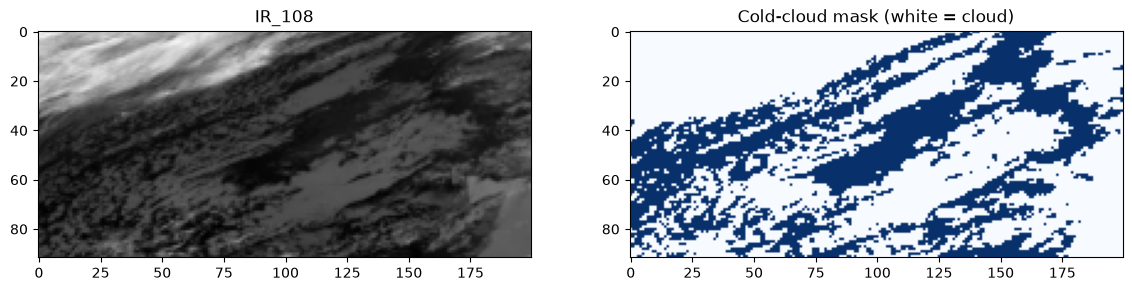

In [46]:
# valid[t, y, x] = True if every channel has a real number at that pixel
valid = np.ones((len(X), *X.shape[-2:]), dtype=bool)
for c in range(X.shape[1]):
    valid &= np.isfinite(X[:, c])

clouds = (to_kelvin(X[:, ir108]) < CLOUD_THRESHOLD_K) & valid    # labels (time, y, x), False where missing

for c in range(X.shape[1]):                                       # fill missing inputs with the channel average
    missing = ~np.isfinite(X[:, c])
    X[:, c][missing] = np.nanmean(X[::50, c].astype(np.float32))

print("inputs:", X.shape, " cloud maps:", clouds.shape)
print(f"{1 - valid.mean():.2%} of pixels are missing;  {clouds[valid].mean():.0%} of valid pixels are cold cloud")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].imshow(X[i, ir108], cmap="gray_r"); ax[0].set_title("IR_108")
ax[1].imshow(clouds[i], cmap="Blues_r"); ax[1].set_title("Cold-cloud mask (white = cloud)")
plt.show()

## 4. Build training examples

One training example = **input:** 6 consecutive frames (30 min) × 6 channels = 36 image layers, plus the 6 matching cloud maps = 42 layers,
**target:** the cloud maps 15, 30 and 60 minutes after the last input frame.

We only use moments where every needed frame exists (there are gaps at the edges of each day and when the
satellite had problems). We look frames up **by their timestamp**, never by "k + 12", because if a frame in
between is missing, "12 positions later" is not "60 minutes later".

We split by **whole days**: frames 5 minutes apart look almost identical, so a random split would let the model
"cheat" by seeing near-copies of the test images during training.

In [47]:
five_min = pd.Timedelta(minutes=5)
position = {t: k for k, t in enumerate(times)}   # time -> index in our arrays
day_number = {d: n for n, d in enumerate(sorted(set(times.normalize())))}   # only days that have data

examples = {"train": [], "val": [], "test": []}
for k, t in enumerate(times):
    past_times = [t - n * five_min for n in reversed(range(HISTORY))]   # oldest first
    future_times = [t + lead * five_min for lead in LEADS]
    if all(s in position for s in past_times + future_times):
        example = ([position[s] for s in past_times], [position[s] for s in future_times])
        examples[split_of_day(day_number[t.normalize()])].append(example)

for name, ex in examples.items():
    n_days = len({times[ex_[0][-1]].normalize() for ex_ in ex})
    print(f"{name:>5}: {len(ex):5d} examples from {n_days} days")
    assert ex, f"No {name} examples: download more days (DAYS in the settings cell)"

train:  3523 examples from 13 days
  val:  1084 examples from 4 days
 test:  1084 examples from 4 days


In [48]:
class CloudDataset(torch.utils.data.Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, n):
        past_idx, future_idx = self.examples[n]
        now = past_idx[-1]
        past = X[past_idx]                                      # (6, 6, H, W)
        past = past.reshape(-1, *past.shape[-2:])               # stack into (36, H, W)
        past = np.concatenate([past, clouds[past_idx]])         # + the 6 past cloud maps -> (42, H, W); last = now
        f = lambda a: torch.tensor(np.asarray(a), dtype=torch.float32)
        return dict(past=f(past),
                    future=f(clouds[future_idx]), future_valid=f(valid[future_idx]),   # (3, H, W)
                    now=f(clouds[now]), now_valid=f(valid[now]))                       # (H, W), for the baselines


# Neighbouring examples are 5 minutes apart and nearly identical (strongly correlated), so every 2nd
# one carries almost all the information. Using half of them halves training time for very little loss.
g = torch.Generator().manual_seed(SEED)
train_loader = torch.utils.data.DataLoader(CloudDataset(examples["train"][::2]), batch_size=16, shuffle=True, generator=g)
val_loader = torch.utils.data.DataLoader(CloudDataset(examples["val"][::2]), batch_size=16)
test_loader = torch.utils.data.DataLoader(CloudDataset(examples["test"]), batch_size=16)

batch = next(iter(train_loader))
print("one batch  -> input:", tuple(batch["past"].shape), " target:", tuple(batch["future"].shape))

one batch  -> input: (16, 42, 92, 200)  target: (16, 3, 92, 200)


## 5. Build the neural network: a small U-Net

A **U-Net** is the classic network for "image in → image out" problems.

* The **encoder** (left side of the "U") shrinks the image step by step, so the network can see large areas
  and learn *how clouds move*.
* The **decoder** (right side) grows it back to full size to draw the prediction.
* **Skip connections** copy fine details from the encoder straight to the decoder, so the output stays sharp.

The output has 3 layers, one per lead time. Each pixel is a score; `sigmoid(score)` turns it into a
cloud probability between 0 and 1.

**The key trick: start from persistence.** Instead of drawing the future cloud map from scratch, the model
takes "clouds stay where they are" as its starting point and the U-Net only learns the *change* (movement,
growth, decay). Before any training the model gives exactly the persistence forecast, so it can only improve
from there. We also give it the past cloud maps as inputs so it doesn't have to rediscover the 270 K rule.

Note: we simply stack the 6 time steps as extra channels, so the network isn't told which layers come
from which moment. It can still learn motion, but models built for sequences (see "Next steps") do it more naturally.

In [49]:
def conv_block(c_in, c_out):
    # Two 3x3 convolutions, each followed by batch-norm and ReLU
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
        nn.Conv2d(c_out, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
    )


class SmallUNet(nn.Module):
    def __init__(self, in_channels, out_channels, width=32):
        super().__init__()
        self.down1 = conv_block(in_channels, width)          # full size
        self.down2 = conv_block(width, width * 2)            # 1/2 size
        self.bottom = conv_block(width * 2, width * 4)       # 1/4 size
        self.up2 = nn.ConvTranspose2d(width * 4, width * 2, 2, stride=2)
        self.dec2 = conv_block(width * 4, width * 2)
        self.up1 = nn.ConvTranspose2d(width * 2, width, 2, stride=2)
        self.dec1 = conv_block(width * 2, width)
        self.out = nn.Conv2d(width, out_channels, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(F.max_pool2d(d1, 2))
        b = self.bottom(F.max_pool2d(d2, 2))
        u2 = self.dec2(torch.cat([self.up2(b), d2], dim=1))   # skip connection from d2
        u1 = self.dec1(torch.cat([self.up1(u2), d1], dim=1))  # skip connection from d1
        return self.out(u1)


class PersistenceUNet(nn.Module):
    # Forecast = persistence ("clouds stay put") + a correction learned by the U-Net.
    def __init__(self, in_channels, out_channels, width=32):
        super().__init__()
        self.unet = SmallUNet(in_channels, out_channels, width)
        nn.init.zeros_(self.unet.out.weight)   # correction starts at exactly 0,
        nn.init.zeros_(self.unet.out.bias)     # so the untrained model IS persistence
        self.confidence = nn.Parameter(torch.tensor(3.0))   # how sure persistence is; learned

    def forward(self, x):
        now = x[:, -1:]                                     # last input layer = current cloud map (0 or 1)
        persistence = self.confidence * (2 * now - 1)       # score +3 where cloudy now, -3 where clear
        return persistence + self.unet(x)


IN_CHANNELS = HISTORY * (len(CHANNELS) + 1)   # 6 frames x (6 channels + 1 cloud map) = 42
model = PersistenceUNet(IN_CHANNELS, len(LEADS)).to(device)
print(f"The model has {sum(p.numel() for p in model.parameters()):,} trainable numbers (parameters)")

The model has 479,108 trainable numbers (parameters)


## 6. Train

Each training step:
1. the model makes a prediction for a batch of examples,
2. the **loss** (binary cross-entropy, ignoring missing pixels) measures how wrong it is,
3. `loss.backward()` works out how to change each parameter to reduce the loss,
4. the **optimizer** (Adam) makes that change.

One **epoch** = one pass over all training examples. After every epoch we also measure the loss on the
**validation** days, which the model never trains on. Training loss almost always keeps going down;
validation loss tells us whether the model is actually getting better at *new* weather. We keep the
version of the model with the lowest validation loss.

epoch  1: train loss 0.2021   val loss 0.1872  <- best
epoch  2: train loss 0.1836   val loss 0.2313
epoch  3: train loss 0.1749   val loss 0.2879
epoch  4: train loss 0.1709   val loss 0.4103
epoch  5: train loss 0.1661   val loss 0.8370
epoch  6: train loss 0.1642   val loss 0.6311
epoch  7: train loss 0.1681   val loss 0.7004
epoch  8: train loss 0.1582   val loss 0.1751  <- best
epoch  9: train loss 0.1579   val loss 0.1787
epoch 10: train loss 0.1555   val loss 0.1857
epoch 11: train loss 0.1521   val loss 0.2373
epoch 12: train loss 0.1510   val loss 0.2200
epoch 13: train loss 0.1496   val loss 0.2089
epoch 14: train loss 0.1490   val loss 0.5714
epoch 15: train loss 0.1481   val loss 0.1830
epoch 16: train loss 0.1463   val loss 0.1973
epoch 17: train loss 0.1450   val loss 0.4116
epoch 18: train loss 0.1428   val loss 0.2194
epoch 19: train loss 0.1419   val loss 0.2322
epoch 20: train loss 0.1407   val loss 0.1477  <- best
epoch 21: train loss 0.1392   val loss 0.2151
epoch 2

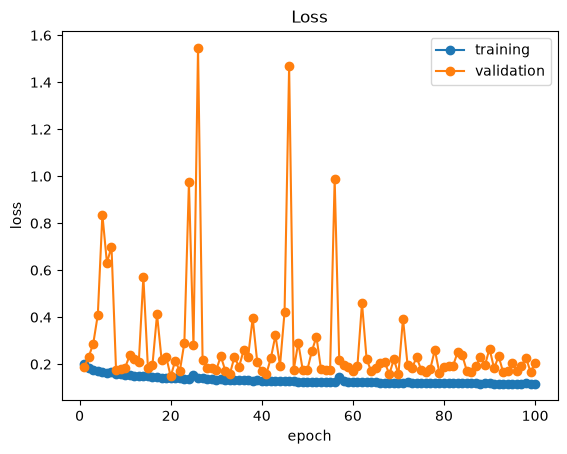

In [51]:
def masked_loss(logits, target, mask):
    loss = F.binary_cross_entropy_with_logits(logits, target, reduction="none")
    return (loss * mask).sum() / mask.sum().clamp(min=1)


def run_epoch(loader, train):
    model.train(train)
    total = 0
    with torch.set_grad_enabled(train):
        for b in loader:
            logits = model(b["past"].to(device))
            loss = masked_loss(logits, b["future"].to(device), b["future_valid"].to(device))
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item()
    return total / len(loader)


EPOCHS = 100
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
history = {"train": [], "val": []}
best_val, best_state = float("inf"), None

for epoch in range(1, EPOCHS + 1):
    history["train"].append(run_epoch(train_loader, train=True))
    history["val"].append(run_epoch(val_loader, train=False))
    better = history["val"][-1] < best_val
    if better:
        best_val, best_state = history["val"][-1], deepcopy(model.state_dict())
    print(f"epoch {epoch:2d}: train loss {history['train'][-1]:.4f}   val loss {history['val'][-1]:.4f}" + ("  <- best" if better else ""))

model.load_state_dict(best_state)   # use the best model, not just the last one

epochs = range(1, EPOCHS + 1)
plt.plot(epochs, history["train"], marker="o", label="training")
plt.plot(epochs, history["val"], marker="o", label="validation")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss")
plt.show()

### Choose the cloud / no-cloud cut-off

The model outputs a probability. Calling everything above 0.5 "cloud" is only a default: blurry forecasts
often need a lower cut-off, or cloud areas shrink. We try many cut-offs on the **validation** days (never the
test days, or we'd be tuning on the exam) and keep, for each lead time, the one with the highest CSI.

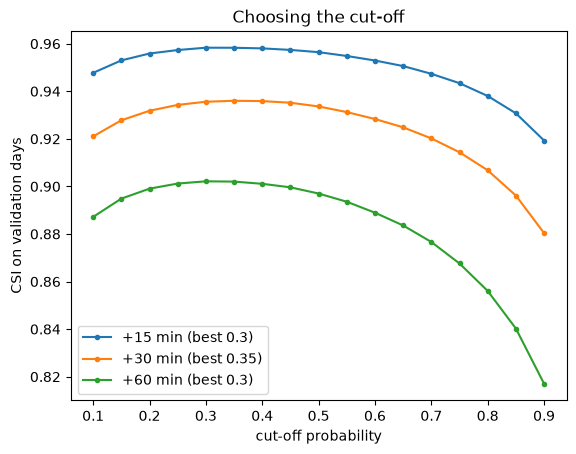

In [52]:
THRESHOLDS = np.round(np.arange(0.1, 0.91, 0.05), 2)
region = torch.tensor(ireland)
tp, fp, fn = (np.zeros((len(THRESHOLDS), len(LEADS))) for _ in range(3))

model.eval()
with torch.no_grad():
    for b in val_loader:
        probs = torch.sigmoid(model(b["past"].to(device))).cpu()
        actual = b["future"] > 0.5
        mask = region & (b["future_valid"] > 0.5) & (b["now_valid"] > 0.5)[:, None]
        for i, th in enumerate(THRESHOLDS):
            p = probs > th
            tp[i] += (p & actual & mask).sum(dim=(0, 2, 3)).numpy()
            fp[i] += (p & ~actual & mask).sum(dim=(0, 2, 3)).numpy()
            fn[i] += (~p & actual & mask).sum(dim=(0, 2, 3)).numpy()

val_csi = tp / np.maximum(tp + fp + fn, 1)
best_threshold = THRESHOLDS[val_csi.argmax(axis=0)]   # one per lead time

for n, lead in enumerate(LEADS):
    plt.plot(THRESHOLDS, val_csi[:, n], marker=".", label=f"+{lead * 5} min (best {best_threshold[n]})")
plt.xlabel("cut-off probability"); plt.ylabel("CSI on validation days"); plt.legend()
plt.title("Choosing the cut-off")
plt.show()

## 7. Evaluate on the test days

A forecast is only useful if it beats simple rules. We compare against two:

* **Persistence:** "the clouds will stay exactly where they are now". Surprisingly hard to beat at short lead times.
* **Advection:** "the clouds keep moving at the same speed and direction as in the last 25 minutes".
  We measure that movement by sliding the oldest input image around until it best lines up with the newest
  one, then slide the current cloud map along by the same speed.

We score only over **Ireland** (the dashed box from section 2). That's what we care about, and it's far from
the edges of our cut-out, where clouds blowing in from outside are impossible for anyone to predict.
Missing pixels are ignored.

For each lead time we count hits (cloud forecast, cloud happened), misses and false alarms, and report:

* **CSI** (critical success index) = hits / (hits + misses + false alarms). 1 = perfect. Ignores the easy clear-sky pixels.
* **POD** (probability of detection) = hits / (hits + misses): how much of the real cloud we caught.
* **FAR** (false alarm ratio) = false alarms / (hits + false alarms): how much forecast cloud wasn't there. Lower is better.
* **Accuracy** = fraction of pixels right. Easy to look good on, shown only for completeness.
* **Skill vs persistence** = (CSI − CSI_persistence) / (1 − CSI_persistence). Above 0 means better than persistence.

In [53]:
def estimate_shift(a, b, max_shift=10):
    # (dy, dx) in pixels that image a has moved by to become image b.
    # Try every shift up to max_shift pixels and keep the one where the moved image a matches b best.
    # (10 shrunk pixels in 25 minutes is ~150 km/h, faster than clouds move.)
    m = max_shift
    target = b[m:-m, m:-m]                       # ignore the border, where shifted-in pixels are unknown
    best, best_err = (0, 0), np.inf
    for dy in range(-m, m + 1):
        for dx in range(-m, m + 1):
            moved = a[m - dy : a.shape[0] - m - dy, m - dx : a.shape[1] - m - dx]
            err = np.abs(moved - target).mean()
            if err < best_err:
                best, best_err = (dy, dx), err
    return best


def shift_image(img, dy, dx):
    # Move an image by (dy, dx) whole pixels; the uncovered edge becomes 0 (clear)
    out = np.zeros_like(img)
    h, w = img.shape
    out[max(dy, 0) : h + min(dy, 0), max(dx, 0) : w + min(dx, 0)] = \
        img[max(-dy, 0) : h + min(-dy, 0), max(-dx, 0) : w + min(-dx, 0)]
    return out


def advection_forecast(past, now):
    # past: (36, H, W) input tensor, now: (H, W) current cloud map -> (3, H, W) forecast
    C = len(CHANNELS)
    oldest, newest = past[ir108].numpy(), past[(HISTORY - 1) * C + ir108].numpy()
    dy, dx = estimate_shift(oldest, newest)
    per_step = np.array([dy, dx]) / (HISTORY - 1)          # pixels per 5 minutes
    return np.stack([shift_image(now.numpy(), *np.round(per_step * lead).astype(int)) for lead in LEADS])

In [54]:
# Quick self-check of the motion estimate: move a random image by a known amount and find it again
test_img = np.random.rand(92, 200)
assert estimate_shift(test_img, np.roll(test_img, (3, -7), axis=(0, 1))) == (3, -7)
print("motion estimate OK")

motion estimate OK


In [55]:
methods = ["U-Net", "Persistence", "Advection"]
counts = {m: np.zeros((len(LEADS), 4)) for m in methods}   # per lead: hits, misses, false alarms, correct negatives

model.eval()
with torch.no_grad():
    for b in test_loader:
        probs = torch.sigmoid(model(b["past"].to(device))).cpu()
        for j in range(len(probs)):
            forecasts = {
                "U-Net": probs[j] > torch.tensor(best_threshold, dtype=torch.float32)[:, None, None],
                "Persistence": (b["now"][j] > 0.5).expand(len(LEADS), -1, -1),
                "Advection": torch.tensor(advection_forecast(b["past"][j], b["now"][j]) > 0.5),
            }
            actual = b["future"][j] > 0.5
            # score only valid pixels inside Ireland, and only where "now" is valid too (so all methods see the same pixels)
            mask = region & (b["future_valid"][j] > 0.5) & (b["now_valid"][j] > 0.5)
            for m, fc in forecasts.items():
                for n in range(len(LEADS)):
                    p, a, k = fc[n], actual[n], mask[n]
                    counts[m][n] += [(p & a & k).sum().item(), (~p & a & k).sum().item(), (p & ~a & k).sum().item(), (~p & ~a & k).sum().item()]


def scores(c):
    hits, misses, false_alarms, correct_neg = c
    csi = hits / max(hits + misses + false_alarms, 1)
    return dict(CSI=csi, POD=hits / max(hits + misses, 1), FAR=false_alarms / max(hits + false_alarms, 1),
                accuracy=(hits + correct_neg) / max(c.sum(), 1))


rows = []
for n, lead in enumerate(LEADS):
    csi_persistence = scores(counts["Persistence"][n])["CSI"]
    for m in methods:
        s = scores(counts[m][n])
        s["skill vs persistence"] = (s["CSI"] - csi_persistence) / (1 - csi_persistence)
        rows.append({"lead": f"+{lead * 5} min", "method": m, **s})
results = pd.DataFrame(rows).set_index(["lead", "method"])
results.round(3)

CSI    POD    FAR  accuracy  skill vs persistence
lead    method                                                          
+15 min U-Net        0.929  0.972  0.046     0.970                 0.396
        Persistence  0.882  0.938  0.064     0.950                 0.000
        Advection    0.900  0.946  0.052     0.958                 0.150
+30 min U-Net        0.893  0.953  0.066     0.955                 0.367
        Persistence  0.831  0.910  0.094     0.926                 0.000
        Advection    0.866  0.930  0.074     0.943                 0.208
+60 min U-Net        0.849  0.948  0.110     0.933                 0.271
        Persistence  0.793  0.888  0.119     0.908                 0.000
        Advection    0.810  0.900  0.110     0.916                 0.084

Let's look at one forecast with our own eyes:

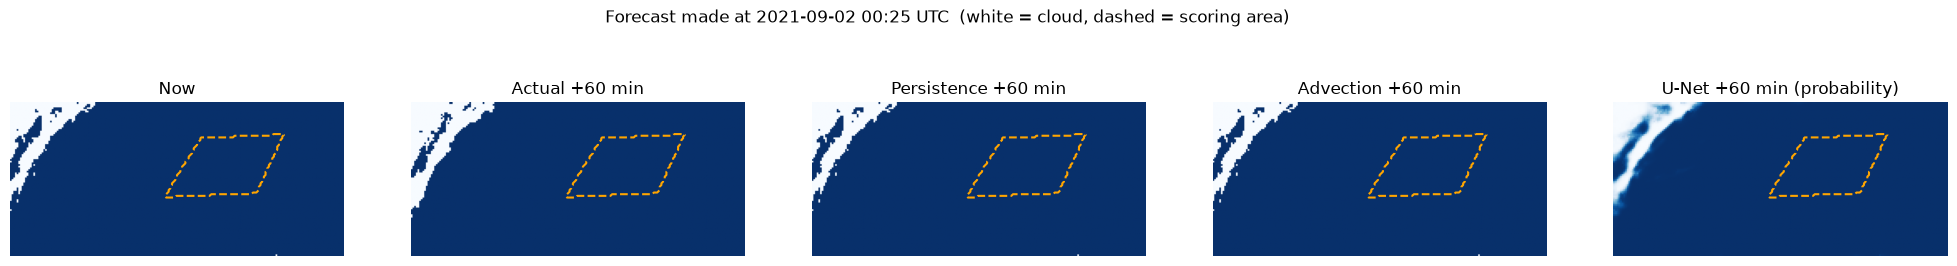

In [56]:
n = len(test_loader.dataset) // 2           # pick a test example
b = test_loader.dataset[n]
with torch.no_grad():
    probability = torch.sigmoid(model(b["past"][None].to(device)))[0].cpu()
advection = advection_forecast(b["past"], b["now"])

lead = 2                                    # 0 = +15 min, 1 = +30 min, 2 = +60 min
m = f"+{LEADS[lead] * 5} min"
panels = [(b["now"], "Now"), (b["future"][lead], f"Actual {m}"), (b["now"], f"Persistence {m}"),
          (advection[lead], f"Advection {m}"), (probability[lead], f"U-Net {m} (probability)")]
fig, ax = plt.subplots(1, 5, figsize=(25, 3.5))
for a, (img, title) in zip(ax, panels):
    a.imshow(img, cmap="Blues_r", vmin=0, vmax=1)
    a.contour(ireland, levels=[0.5], colors="orange", linestyles="--")
    a.set_title(title); a.axis("off")
fig.suptitle(f"Forecast made at {times[test_loader.dataset.examples[n][0][-1]]:%Y-%m-%d %H:%M} UTC  (white = cloud, dashed = scoring area)")
plt.show()

## 8. Save the trained model

In [57]:
Path("models").mkdir(exist_ok=True)
torch.save({"state_dict": model.state_dict(), "config": config, "history": HISTORY, "leads": LEADS,
            "thresholds": best_threshold.tolist()},
           "models/notebook_unet.pt")
print("Saved to models/notebook_unet.pt")

# To load it again later:
# saved = torch.load("models/notebook_unet.pt")
# model = PersistenceUNet(HISTORY * (len(CHANNELS) + 1), len(LEADS))
# model.load_state_dict(saved["state_dict"])

Saved to models/notebook_unet.pt
